In [1]:
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
pandas2ri.activate()

In [2]:
import os
import sys

In [3]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
import networkx as nx
from netgraph import Graph, InteractiveGraph

In [4]:
import scanpy as sc
import anndata as ad
import scvelo as scv

Jax plugin configuration error: Plugin module jax_plugins.xla_cuda12 does not exist


In [25]:
%matplotlib inline
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=100, 
    facecolor="white",
    frameon=False,
)

matplotlib.rcParams['font.family'] = "Arial"
matplotlib.rcParams['grid.alpha'] = 0

## Explore the data structure(res.rds)

In [6]:
path = "/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/datasets/grn100_tree1_1000_cells110_genes_sigma0.1_1/"

In [7]:
readRDS = robjects.r['readRDS']

In [8]:
res = readRDS(path + "res.rds")

In [9]:
res_names = list(res.names)

In [10]:
res_names

['.grn',
 '.options',
 '.n',
 'region_to_gene',
 'atacseq_data',
 'giv',
 'kinetic_params',
 'num_genes',
 'cif',
 'hge_scale',
 'counts',
 'cell_meta',
 'atac_counts',
 'region_to_tf',
 'grn_params']

In [11]:
counts_rna = res["counts"]

In [12]:
counts_rna

array([[1.000e+00, 7.000e+00, 5.000e+00, ..., 3.000e+00, 1.400e+01,
        2.000e+00],
       [0.000e+00, 4.000e+00, 0.000e+00, ..., 1.000e+00, 1.000e+00,
        5.300e+01],
       [5.500e+01, 3.100e+01, 3.900e+01, ..., 1.190e+02, 6.600e+01,
        7.000e+01],
       ...,
       [7.000e+00, 2.300e+01, 2.000e+00, ..., 2.800e+01, 4.800e+01,
        4.000e+00],
       [1.200e+01, 2.000e+01, 1.000e+01, ..., 1.900e+01, 2.000e+01,
        2.100e+01],
       [7.000e+00, 1.000e+01, 5.000e+00, ..., 3.357e+03, 2.554e+03,
        9.420e+02]])

In [13]:
counts_atac = res["atac_counts"]

In [14]:
counts_atac

array([[ 0.        ,  2.39863821,  3.90822698, ...,  0.        ,
         0.20689107,  0.67996733],
       [ 0.        ,  0.        ,  3.34166275, ...,  3.12066243,
         1.42099603,  1.18689951],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.39539102,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  1.07754466,  1.66422628, ...,  3.62183633,
         0.        ,  2.04350977],
       [10.20387896, 12.75508821, 11.64582291, ...,  0.20742613,
         4.94113832,  6.46036589]])

In [15]:
res[".grn"]

params,[RTYPES.VECSXP]
name_map,[RTYPES.INTSXP]
targets,[RTYPES.REALSXP]
regulators,[RTYPES.REALSXP]
n_tgt,[RTYPES.INTSXP]
n_reg,[RTYPES.INTSXP]
geff,[RTYPES.REALSXP]


In [16]:
res[".grn"].rx2("regulators")

array([ 2.,  6., 10., 19., 80., 91.])

In [17]:
res[".grn"].rx2("targets")

array([  1.,   3.,   4.,   5.,   7.,   8.,   9.,  11.,  12.,  13.,  14.,
        15.,  16.,  17.,  18.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,
        27.,  28.,  29.,  30.,  31.,  32.,  33.,  34.,  35.,  36.,  37.,
        38.,  39.,  40.,  41.,  42.,  43.,  44.,  45.,  46.,  47.,  48.,
        49.,  50.,  51.,  52.,  53.,  54.,  55.,  56.,  57.,  58.,  59.,
        60.,  61.,  62.,  63.,  64.,  65.,  66.,  67.,  68.,  69.,  70.,
        71.,  72.,  73.,  74.,  75.,  76.,  77.,  78.,  79.,  81.,  82.,
        83.,  84.,  85.,  86.,  87.,  88.,  89.,  90.,  92.,  93.,  94.,
        95.,  96.,  97.,  98.,  99., 100.])

In [18]:
cell_meta = robjects.conversion.rpy2py(res["cell_meta"])

In [19]:
cell_meta

,cell_id,pop,depth
cell1,cell1,2_1,0.000000
cell2,cell2,2_1,0.001001
cell3,cell3,2_1,0.002002
cell4,cell4,2_1,0.003003
cell5,cell5,2_1,0.004004
...,...,...,...
cell996,cell996,2_1,0.995996
cell997,cell997,2_1,0.996997
cell998,cell998,2_1,0.997998
cell999,cell999,2_1,0.998999


## GRN groundtruth

In [145]:
grn = robjects.conversion.rpy2py(res[".grn"].rx2("params"))

In [146]:
grn

,target,regulator,effect
1,16.0,10.0,1.768699
2,29.0,10.0,1.675360
3,62.0,10.0,3.723509
4,55.0,10.0,2.866182
5,81.0,80.0,4.020744
...,...,...,...
126,33.0,19.0,4.496424
127,43.0,19.0,1.594693
128,27.0,19.0,3.342843
129,31.0,19.0,4.863627


In [147]:
grn = grn.loc[:, ["regulator", "target", "effect"]]

In [148]:
grn["target"] = "gene" + grn["target"].astype("int").astype("str")
grn["regulator"] = "gene" + grn["regulator"].astype("int").astype("str")

In [149]:
grn["sign"] = grn["effect"] > 3

In [150]:
grn.head()

,regulator,target,effect,sign
1,gene10,gene16,1.768699,False
2,gene10,gene29,1.675360,False
3,gene10,gene62,3.723509,True
4,gene10,gene55,2.866182,False
5,gene80,gene81,4.020744,True


In [151]:
grn = grn.sort_values(by = ["regulator"])

In [152]:
G = nx.DiGraph()
for _, row in grn.iterrows():
    regulator = row['regulator']
    target = row['target']
    attributes = {key: row[key] for key in row.index if key not in ['regulator', 'target']}
    G.add_edge(regulator, target, **attributes)

In [153]:
regulators = grn["regulator"].unique()

In [154]:
node_color_df = pd.DataFrame(index=G.nodes())
node_color_df["color"] = "#DAADAF"
for regulator in regulators:
    node_color_df.loc[regulator, "color"] = "#BE5454"

node_color = node_color_df["color"].to_dict()

In [155]:
node_size_df = pd.DataFrame(index=G.nodes())
node_size_df["size"] = 2
for regulator in regulators:
    node_size_df.loc[regulator, "size"] = 3
node_size = node_size_df["size"].to_dict()


In [156]:
node_shape_df = pd.DataFrame(index=G.nodes())
node_shape_df["shape"] = "o"
for regulator in regulators:
    node_shape_df.loc[regulator, "shape"] = "8"
node_shape = node_shape_df["shape"].to_dict()

<Axes: xlabel='effect', ylabel='Density'>

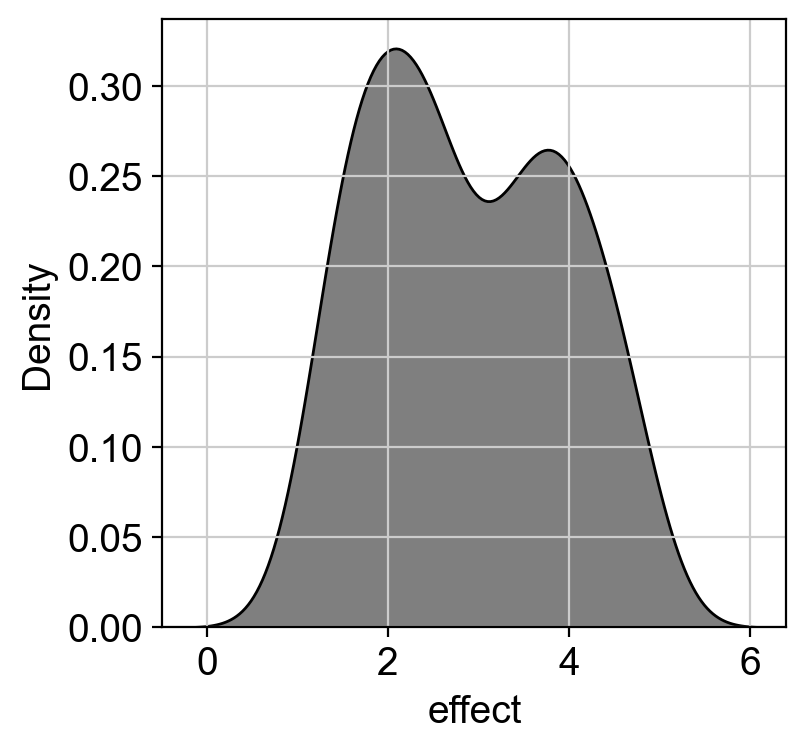

In [157]:
sns.kdeplot(grn["effect"], fill=True, color="black", alpha=0.5)

In [158]:

edge_color_df = pd.DataFrame(index=G.edges())
edge_color_df["color"] = "gray"  

for u, v, attrs in G.edges(data=True):
    sign = attrs.get('sign')
    if sign:
        edge_color_df.loc[(u, v), 'color'] = 'black'
edge_color = edge_color_df["color"].to_dict()

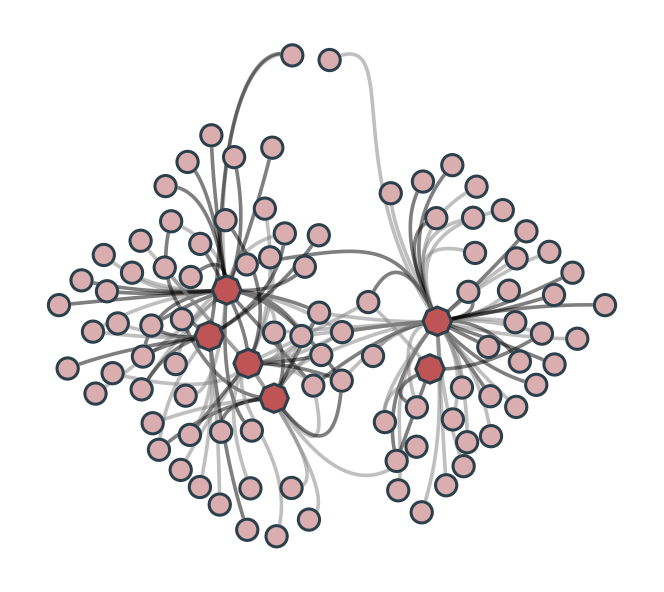

In [159]:
Graph(G, 
      node_edge_width=0.5, 
      node_size=node_size,
      node_color=node_color,
      node_shape=node_shape,
      node_layout="spring",
      edge_layout="curved", 
      edge_layout_kwargs=dict(k=0.1),
      edge_width=0.6,
      edge_color=edge_color,
      arrows=False)

plt.show()

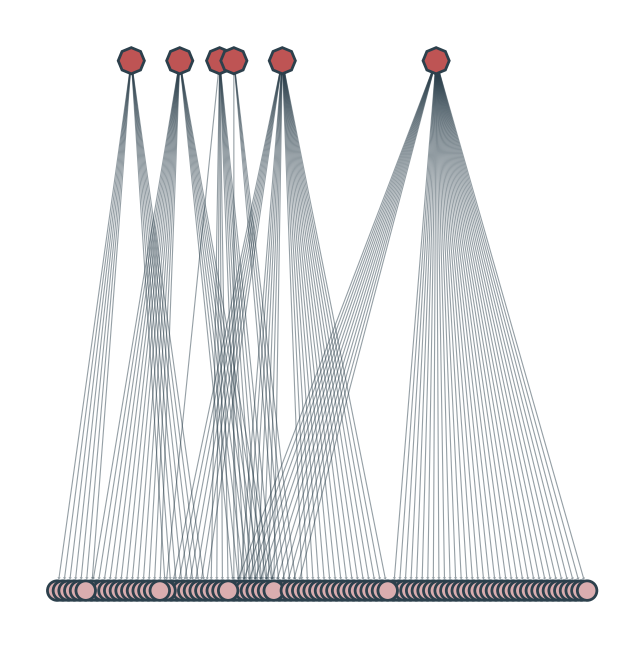

In [61]:
Graph(G, 
      node_edge_width=0.5, 
      node_size=node_size,
      node_color=node_color,
      node_shape=node_shape,
      node_layout="dot",
      edge_layout_kwargs=dict(k=0.1),
      edge_width=0.2,
      arrows=True)

plt.show()

## Convert to anndata

In [35]:
adata = ad.AnnData(X = counts_rna.T, obs = cell_meta)

In [36]:
adata

AnnData object with n_obs × n_vars = 1000 × 110
    obs: 'cell_id', 'pop', 'depth'

In [37]:
adata.var_names

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '100', '101', '102', '103', '104', '105', '106', '107', '108', '109'],
      dtype='object', length=110)

In [38]:
adata.var.index = ["gene" + str(x + 1) for x in range(adata.shape[1])]

In [39]:
adata.var_names

Index(['gene1', 'gene2', 'gene3', 'gene4', 'gene5', 'gene6', 'gene7', 'gene8',
       'gene9', 'gene10',
       ...
       'gene101', 'gene102', 'gene103', 'gene104', 'gene105', 'gene106',
       'gene107', 'gene108', 'gene109', 'gene110'],
      dtype='object', length=110)

In [40]:
# preprocessing, counts_per_cell_after cannot be too small, or import_anndata_as_raw_count will fail
sc.pp.normalize_per_cell(adata, counts_per_cell_after = 100)
adata.raw = adata
adata.layers["counts"] = adata.raw.X.copy()
# log transformation and scaling
sc.pp.log1p(adata)
# sc.pp.scale(adata)
# dimension reduction
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)

sc.tl.leiden(adata, resolution=0.5)

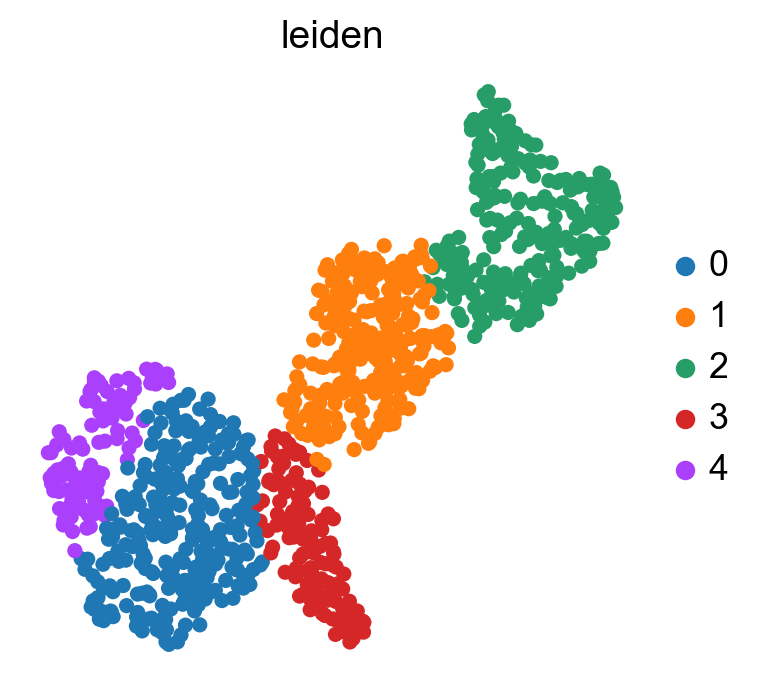

In [41]:
sc.tl.umap(adata)
sc.pl.umap(adata, color = ["leiden"])

In [42]:
adata

AnnData object with n_obs × n_vars = 1000 × 110
    obs: 'cell_id', 'pop', 'depth', 'n_counts', 'leiden'
    uns: 'log1p', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [43]:
adata.obs_names

Index(['cell1', 'cell2', 'cell3', 'cell4', 'cell5', 'cell6', 'cell7', 'cell8',
       'cell9', 'cell10',
       ...
       'cell991', 'cell992', 'cell993', 'cell994', 'cell995', 'cell996',
       'cell997', 'cell998', 'cell999', 'cell1000'],
      dtype='object', length=1000)

In [44]:
sc.tl.diffmap(adata)

In [46]:
def select_root_ixs(adata):
    """
    Select root index from diffmap embedding
    """
    root_ixs_max = adata.obsm['X_diffmap'][:, 1].argmax()
    root_ixs_min = adata.obsm['X_diffmap'][:, 1].argmin()
    
    if root_ixs_max > root_ixs_min:
        root_ixs = root_ixs_min 
    else:
        root_ixs = root_ixs_max

    return root_ixs

In [47]:
root_ixs = select_root_ixs(adata)

In [48]:
root_ixs

36

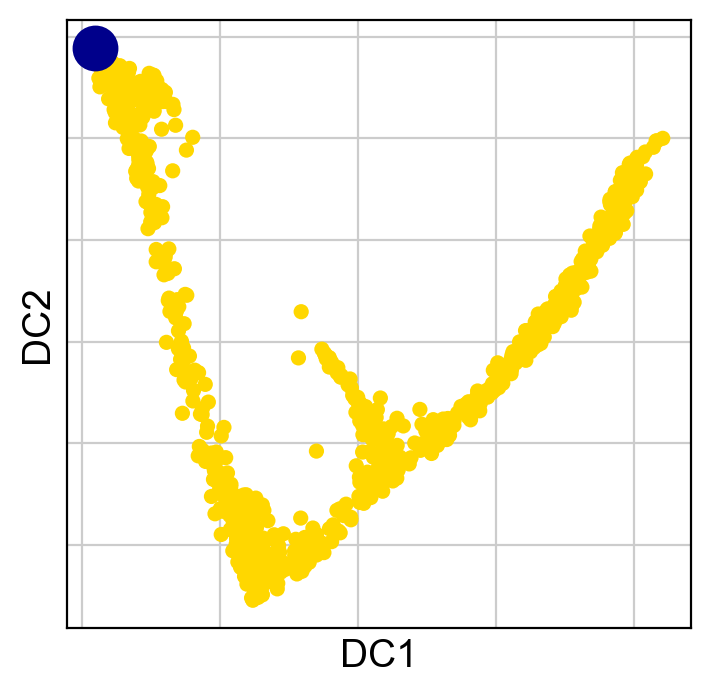

In [49]:
scv.pl.scatter(adata,
                basis="diffmap",
                c=[root_ixs],
                legend_loc="right",
                components=["1, 2"],
                frameon=True)

adata.uns["iroot"] = root_ixs

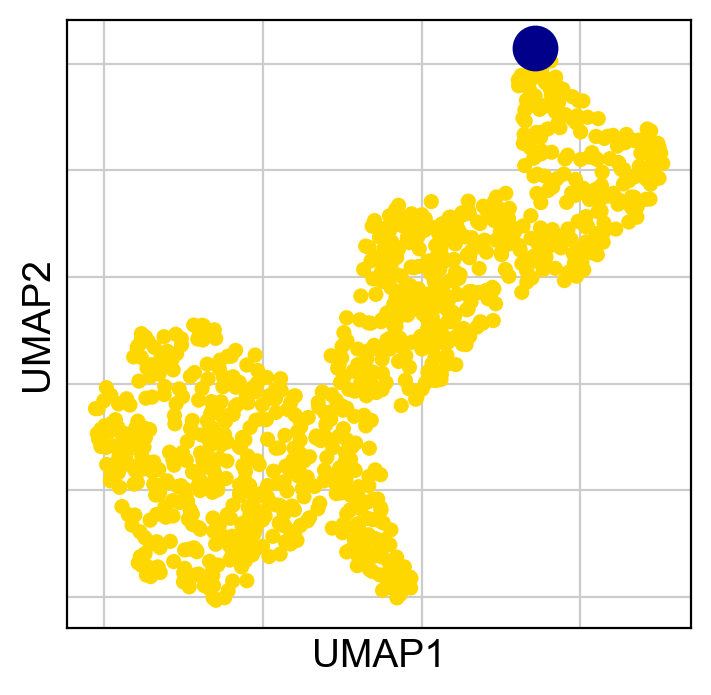

In [50]:
scv.pl.scatter(adata,
                basis="umap",
                c=[root_ixs],
                legend_loc="right",
                components=["1, 2"],
                frameon=True)

adata.uns["iroot"] = root_ixs

In [51]:
sc.tl.dpt(adata)

In [52]:
adata

AnnData object with n_obs × n_vars = 1000 × 110
    obs: 'cell_id', 'pop', 'depth', 'n_counts', 'leiden', 'dpt_pseudotime'
    uns: 'log1p', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'diffmap_evals', 'iroot'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

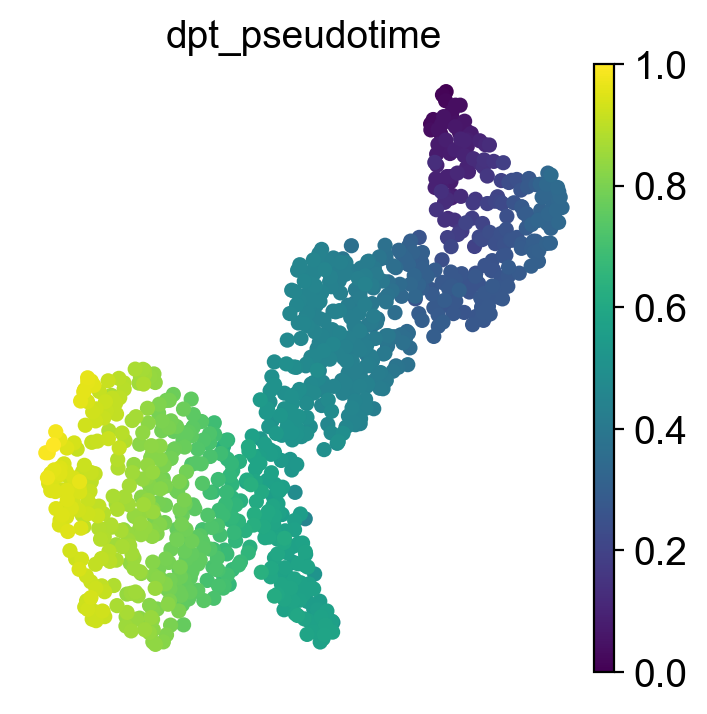

In [53]:
sc.pl.umap(adata, color=["dpt_pseudotime"])

In [54]:
adata

AnnData object with n_obs × n_vars = 1000 × 110
    obs: 'cell_id', 'pop', 'depth', 'n_counts', 'leiden', 'dpt_pseudotime'
    uns: 'log1p', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'diffmap_evals', 'iroot'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

Text(0.5, 1.0, 'Root Index: 36')

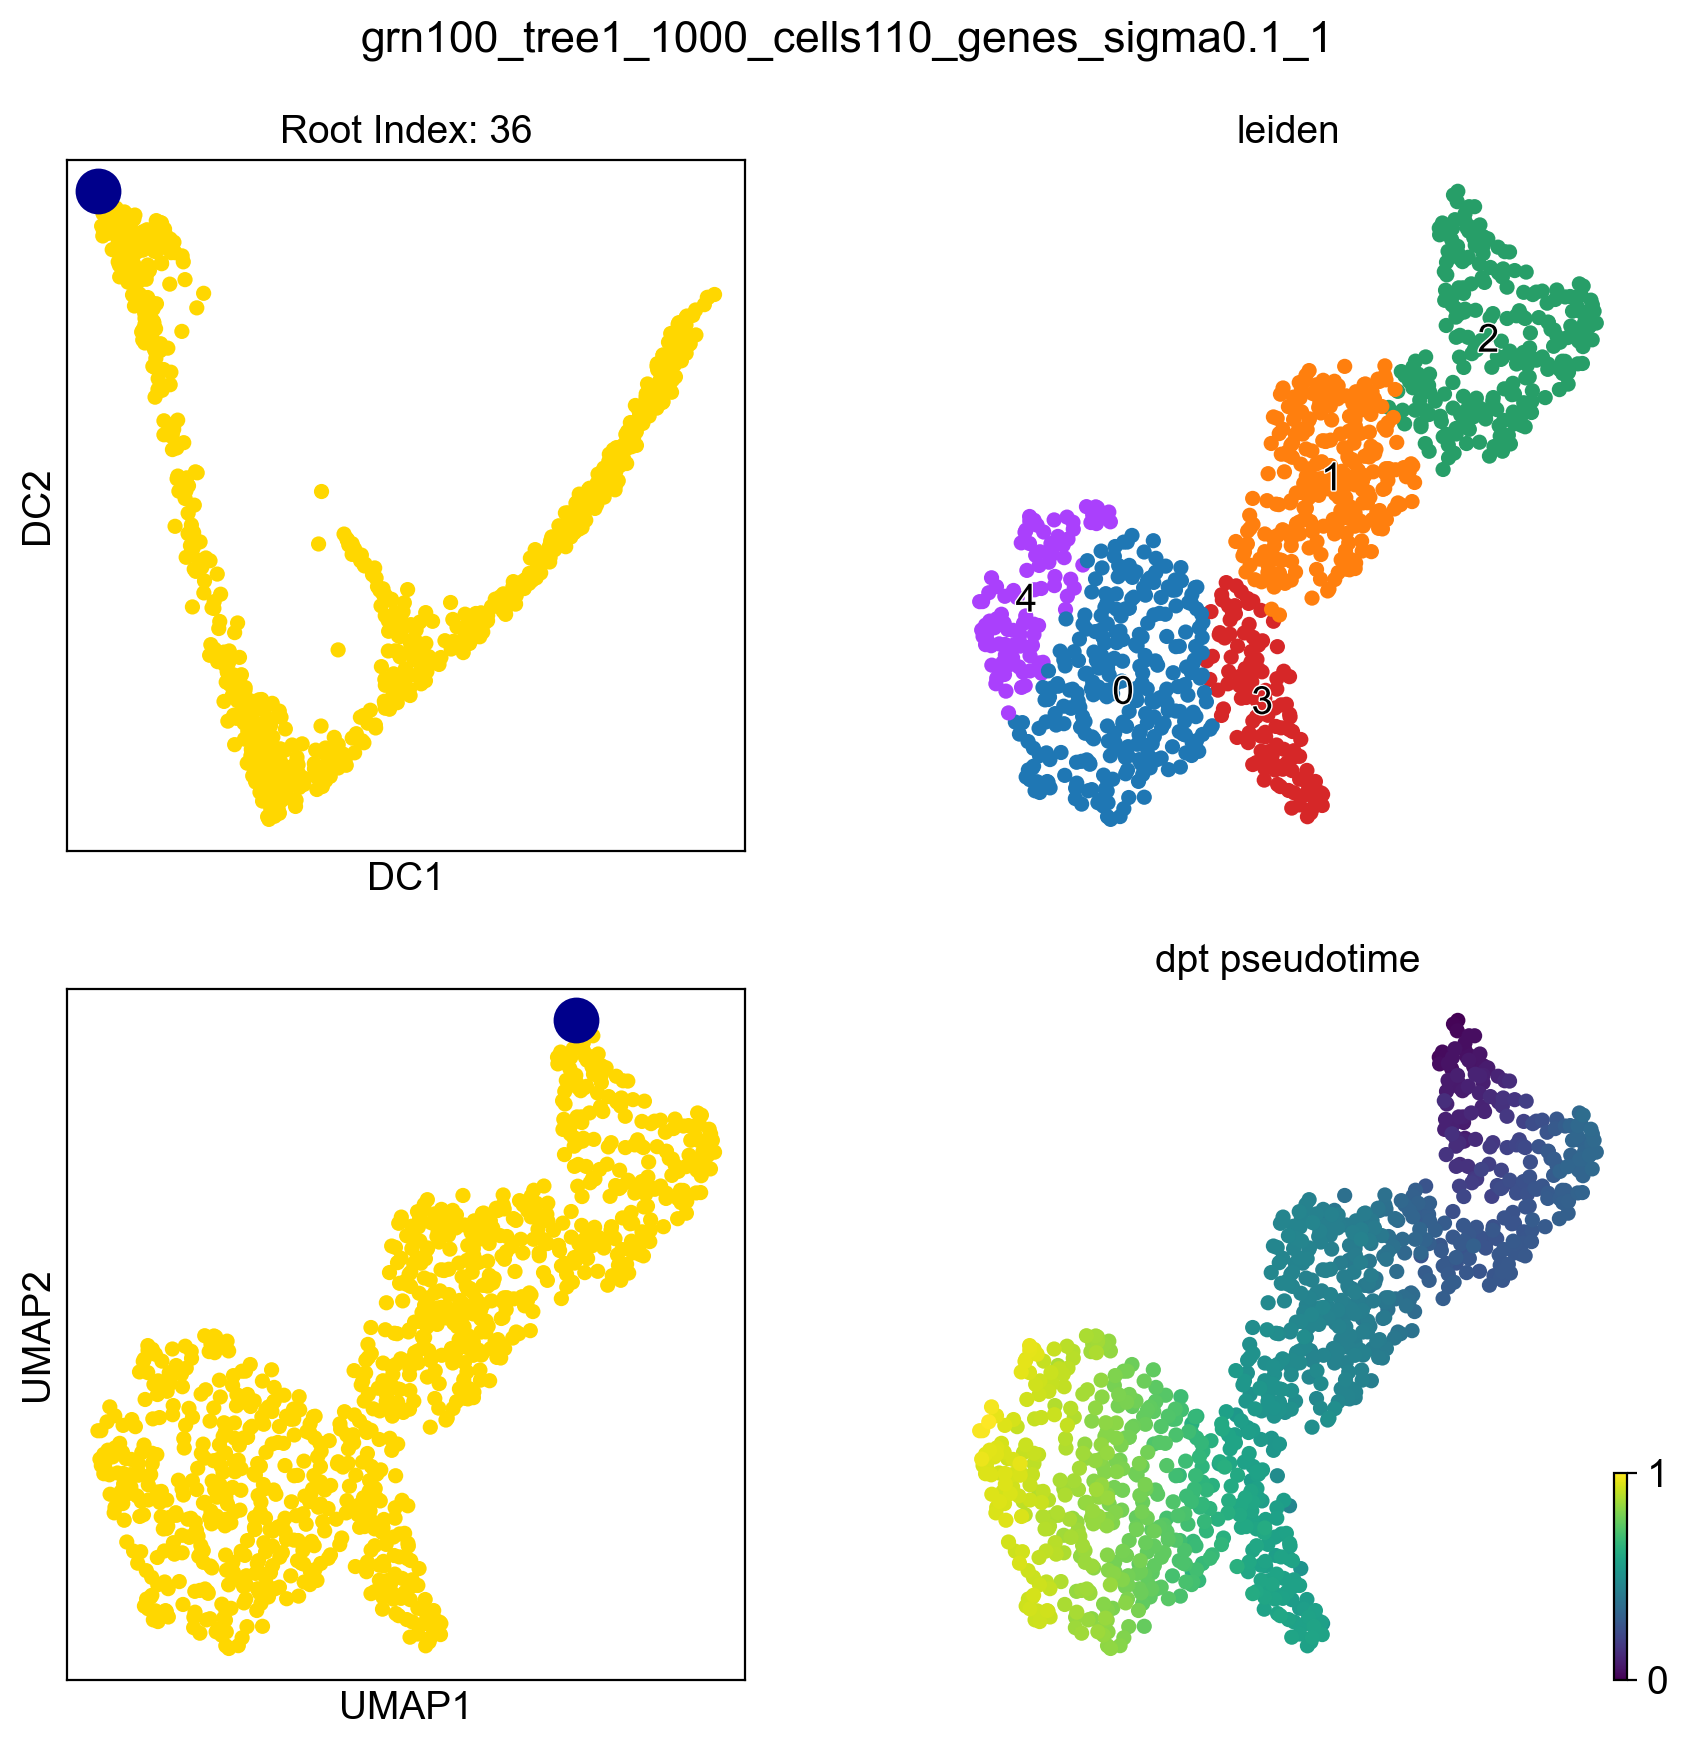

In [55]:
matplotlib.rcParams["grid.alpha"] = 0


fig, ax = plt.subplots(2, 2, figsize=(10, 10), gridspec_kw={"wspace": 0.3})
ax1_dict = scv.pl.scatter(adata, basis="diffmap", color=[root_ixs], components=["1, 2"], frameon=True, ax=ax[0, 0], show=False)
ax2_dict = scv.pl.scatter(adata, basis="umap", color=[root_ixs], frameon=True, ax=ax[1, 0], show=False)
ax3_dict = scv.pl.scatter(adata, basis="umap", color=["leiden"], frameon=False, ax=ax[0, 1], show=False)
ax4_dict = scv.pl.scatter(adata, basis="umap", color=["dpt_pseudotime"], frameon=False, ax=ax[1, 1], show=False, color_map="viridis")

# title
fig.suptitle("grn100_tree1_1000_cells110_genes_sigma0.1_1", fontsize=16, fontweight="bold", x=0.57)
ax[0, 0].set_title(f"Root Index: {root_ixs}", fontsize=14, fontweight="bold")

## Base GRN

In [56]:
region2gene = res["region_to_gene"]

In [57]:
region2gene.shape

(330, 110)

In [58]:
region2tf = res["region_to_tf"]

In [59]:
region2tf.shape

(330, 6)

In [60]:
base_grn = (region2gene.T @ region2tf > 0).astype(int)

In [61]:
base_grn.shape

(110, 6)

In [64]:
grn = res[".grn"].rx2("geff")
regulators = ["gene" + str(int(x)) for x in res[".grn"].rx2("regulators")] 

adata.var["is_reg"] = False
adata.var.loc[regulators, "is_reg"] = True
adata.var["is_target"] = True

In [65]:
base_grn = pd.DataFrame(data = base_grn, index = adata.var.index.values, columns = regulators)

In [66]:
base_grn.head()

,gene2,gene6,gene10,gene19,gene80,gene91
gene1,1,1,1,1,0,0
gene2,0,0,0,0,0,0
gene3,0,0,0,0,0,0
gene4,1,0,1,0,0,0
gene5,1,1,1,1,0,0


In [67]:
adata.varm["base_grn"] = base_grn

## Add noise to base_grn

In [6]:
from rich.table import Table
from rich.console import Console
def add_noise_to_grn(region2gene, region2tf, p, random_state=None, show_table=False):
    """
    Add noise to two dense binary matrices and return the noisy GRN.

    Parameters:
    - region2gene: np.ndarray of shape (n_regions, n_genes)
    - region2tf: np.ndarray of shape (n_regions, n_tfs)
    - p: float, noise level (e.g., 0.01, 0.1, 0.5)
    - random_state: int or None

    Returns:
    - noisy_grn: np.ndarray of shape (n_tfs, n_genes), binary matrix
    """
    rng = np.random.default_rng(random_state)

    def add_and_remove_noise(mat):
        mat = mat.copy()
        n_total = mat.size
        n_pos = np.count_nonzero(mat)
        ppos = n_pos / n_total
        scale = 50 * ppos

        # 1. Remove existing edges with probability p
        remove_mask = (mat == 1) & (rng.random(mat.shape) < p)
        mat[remove_mask] = 0

        # 2. Add new edges where mat == 0, with probability scale * p
        add_mask = (mat == 0) & (rng.random(mat.shape) < (scale * p))
        mat[add_mask] = 1

        return mat

    region2gene_noisy = add_and_remove_noise(region2gene)
    region2tf_noisy = add_and_remove_noise(region2tf)

    # Multiply: (region2tf.T @ region2gene) => shape (n_tfs, n_genes)
    noisy_grn = (region2gene_noisy.T @ region2tf_noisy > 0).astype(int)
    
    # Compare the difference between the original and noisy GRN
    original_grn = (region2gene.T @ region2tf > 0).astype(int)
    diff = noisy_grn - original_grn
    
    # Table
    if show_table:
        table = Table(title="Statistics of Base GRN")
        table.add_column("Metric", justify="center")
        table.add_column("Original GRN", justify="center")
        table.add_column("Noisy GRN", justify="center")
        table.add_column("Difference", justify="center")
        # table.add_row("Shape", str(original_grn.shape), str(noisy_grn.shape), str(diff.shape))
        table.add_row("Density", f"{np.mean(original_grn):.4f}", f"{np.mean(noisy_grn):.4f}", f"{np.mean(diff):.4f}")
        table.add_row("Non-zero elements", str(np.count_nonzero(original_grn)), str(np.count_nonzero(noisy_grn)), str(np.count_nonzero(diff)))
        
        console = Console()
        console.print(table)

    # Optional: binarize the GRN
    return noisy_grn

## Batch 

In [19]:
def select_root_ixs(adata):
    """
    Select root index from diffmap embedding
    """
    root_ixs_max = adata.obsm['X_diffmap'][:, 1].argmax()
    root_ixs_min = adata.obsm['X_diffmap'][:, 1].argmin()
    
    if root_ixs_max > root_ixs_min:
        root_ixs = root_ixs_min 
    else:
        root_ixs = root_ixs_max

    return root_ixs

In [20]:
def res_to_h5ad(path, plot=False, root_ixs=None):
    
    ds_name = path.split("/")[-2]
    readRDS = robjects.r['readRDS']
    res = readRDS(path + "res.rds")
    
    counts_rna = res["counts"]
    counts_rna = counts_rna.astype(np.float32)
    counts_rna = csr_matrix(counts_rna)
    
    cell_meta = robjects.conversion.rpy2py(res["cell_meta"])
    
    adata = ad.AnnData(X = counts_rna.T, obs = cell_meta)
    
    adata.var_names = ["gene" + str(x + 1) for x in range(adata.shape[1])]
    
    # preprocessing, counts_per_cell_after cannot be too small, or import_anndata_as_raw_count will fail
    adata.layers["counts"] = adata.X.copy()
    
    sc.pp.normalize_per_cell(adata, counts_per_cell_after = 100)
    # log transformation and scaling
    sc.pp.log1p(adata)
    # sc.pp.scale(adata)
    # dimension reduction
    sc.tl.pca(adata, svd_solver='arpack')
    sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
    
    sc.tl.umap(adata)
    
    sc.tl.leiden(adata, resolution = 0.5)
    
    sc.tl.diffmap(adata)
    
    if root_ixs is None:
        root_ixs = select_root_ixs(adata)
        
    # print("root_ixs: ", root_ixs)
    adata.uns["iroot"] = root_ixs   
    
    sc.tl.dpt(adata)
    adata.obs["palantir_pseudotime"] = adata.obs["dpt_pseudotime"].copy()
    
    PseudoTimeDF = adata.obs['palantir_pseudotime']
    PseudoTimeDF.to_csv(path + "PseudoTime.csv")
    
    region2gene = res["region_to_gene"]
    region2tf = res["region_to_tf"]
    
    base_grn = (region2gene.T @ region2tf > 0).astype(int)
    regulators = ["gene" + str(int(x)) for x in res[".grn"].rx2("regulators")] 
    
    adata.var["is_reg"] = False
    adata.var.loc[regulators, "is_reg"] = True
    adata.var["is_target"] = True
    
    base_grn = pd.DataFrame(data = base_grn, index = adata.var.index.values, columns = regulators)
    adata.varm["base_grn"] = base_grn
    
    # add noise to grn
    for p in [0.01, 0.05, 0.1, 0.5]:
        noisy_grn = add_noise_to_grn(region2gene, region2tf, p=p, random_state=42, show_table=False)
        noisy_grn = pd.DataFrame(data = noisy_grn, index = adata.var.index.values, columns = regulators)
        adata.varm[f"noisy_grn_{p}"] = noisy_grn
    
    # adata.X = adata.layers["counts"].copy()
    adata.X = csr_matrix(adata.X)
    adata.write(path + "res.h5ad")
    
    if plot:
        fig, ax = plt.subplots(2, 2, figsize=(10, 10))
        ax1_dict = scv.pl.scatter(adata, basis="diffmap", color=[root_ixs], components=["1, 2"], frameon=True, ax=ax[0, 0], show=False)
        ax2_dict = scv.pl.scatter(adata, basis="umap", color=[root_ixs], frameon=True, ax=ax[1, 0], show=False)
        ax3_dict = scv.pl.scatter(adata, basis="umap", color=["leiden"], frameon=False, ax=ax[0, 1], show=False)
        ax4_dict = scv.pl.scatter(adata, basis="umap", color=["dpt_pseudotime"], frameon=False, ax=ax[1, 1], show=False, color_map="viridis")
        fig.suptitle(ds_name, fontsize=16, fontweight="bold", x=0.57)
        ax[0, 0].set_title(f"Root Index: {root_ixs}", fontsize=14, fontweight="bold")
        fig.savefig(path + "res.png", dpi=300, bbox_inches='tight')
    
    return adata
    

In [21]:
import os
ds_dir = "/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/datasets/"
datasets = [ds_dir + name + "/" for name in os.listdir(ds_dir) if os.path.isdir(os.path.join(ds_dir, name))]

In [22]:
len(datasets)

48

In [23]:
datasets[0]

'/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/datasets/grn100_noise_tree1_1000_cells110_genes_sigma0.1_5/'

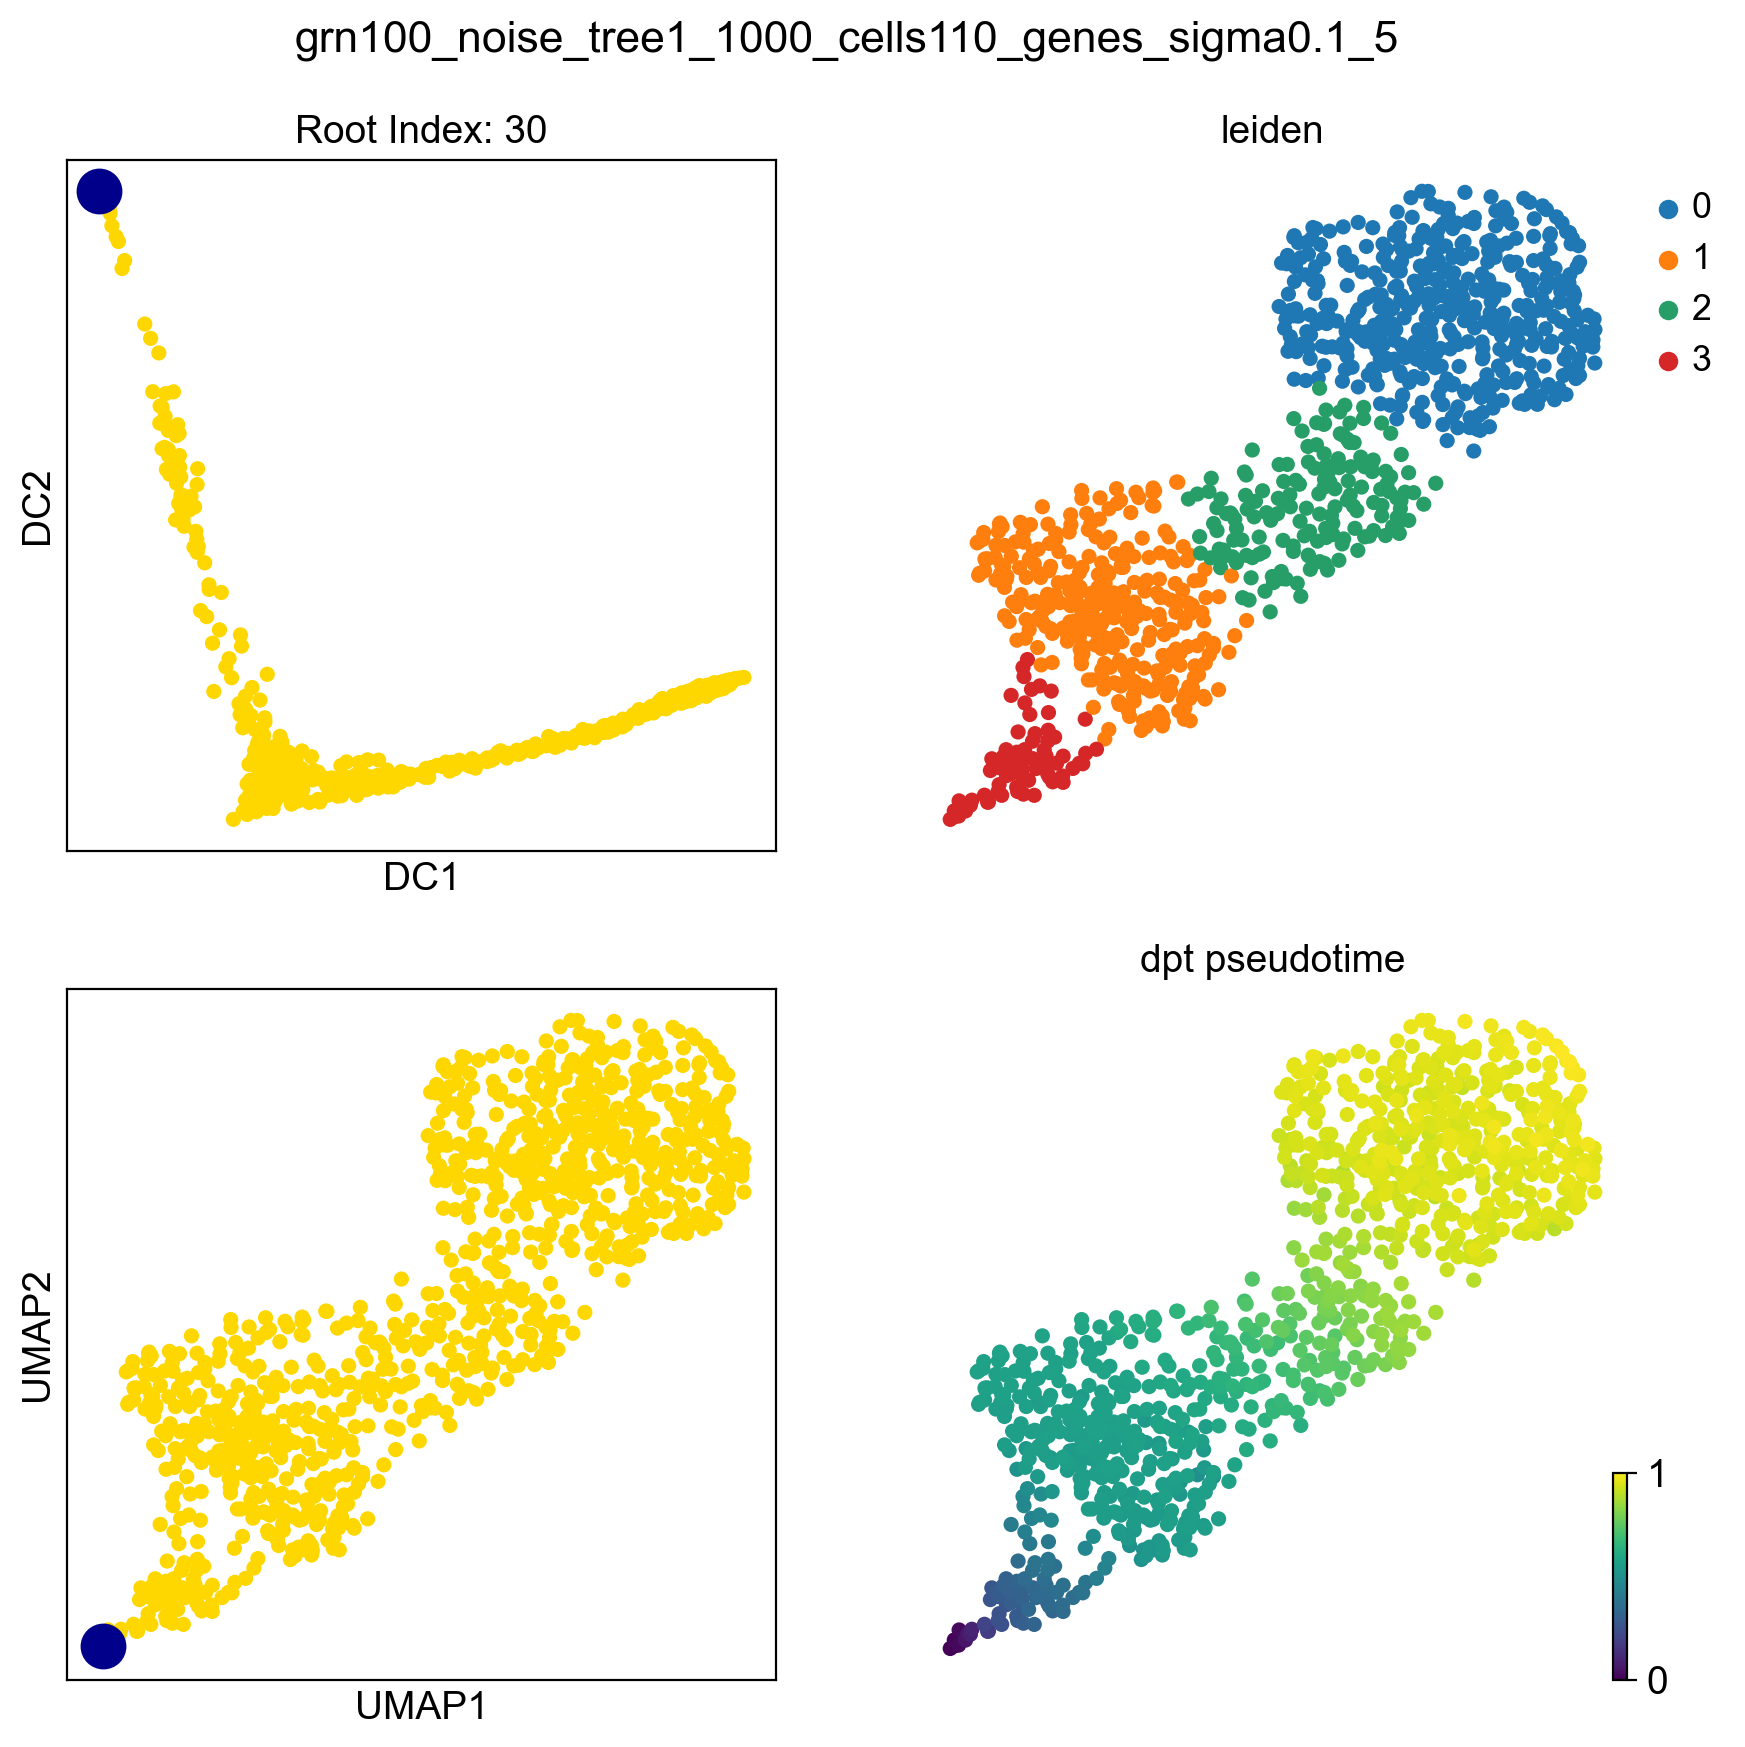

In [26]:
adata = res_to_h5ad(datasets[0], plot=True)

In [27]:
from tqdm.auto import tqdm
for dataset in tqdm(datasets, desc=f"Processing datasets: ", unit=f"{datasets[0].split('/')[-2]}"):
    res_to_h5ad(dataset, plot=False)

Processing datasets:   0%|          | 0/48 [00:00<?, ?grn100_noise_tree1_1000_cells110_genes_sigma0.1_5/s]